# IMDb Rating vs Meta Score Analysis

## Overview

This notebook investigates the relationship between IMDb Rating and Meta Score using the IMDb Top 1000 Movies dataset.

The analysis focuses on:
- identifying missing values in the relevant variables,
- preparing the data for analysis,
- measuring the strength and direction of the relationship using Pearson correlation,
- examining mean IMDb ratings across different Meta Score ranges,
- visualizing the relationship between the two variables.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Research Question

**Is there a relationship between IMDb Rating and Meta Score?**

To answer this question, we will:
- handle missing values,
- calculate the correlation coefficient,
- visualize the relationship using a scatter plot.

## Data Loading

The IMDb Top 1000 Movies dataset is loaded into a Pandas DataFrame for analysis.

In [ ]:
df = pd.read_csv("../data/imdb_top_1000.csv.xls")

## Missing Value Analysis

Before performing the analysis, the relevant variables are checked for missing values.

Missing values in `Meta_score` and `IMDB_Rating` are identified and their counts and percentages are calculated.

In [ ]:
missing_value = pd.DataFrame({
    "Missing Count": df[["Meta_score", "IMDB_Rating"]].isnull().sum(),
    "Missing Value Percentage": (df[["Meta_score", "IMDB_Rating"]].isnull().sum() / len(df)) * 100
})

missing_value

## Data Preparation

Rows with missing values in either `Meta_score` or `IMDB_Rating` are excluded from the analysis.

A separate DataFrame is created to preserve the original dataset while ensuring that only complete observations are used in the analysis.

In [ ]:
analysis_df = df[df[["Meta_score", "IMDB_Rating"]].notnull().all(axis=1)].copy()

original_rows = len(df)
remaining_rows = len(analysis_df)

print(f"Original rows: {original_rows}")
print(f"Rows used for analysis: {remaining_rows}")
print(f"Rows excluded: {original_rows - remaining_rows}")

## Correlation Analysis

Pearson's correlation coefficient is used to measure the strength and direction of the linear relationship between IMDb Rating and Meta Score.

The correlation is calculated using all available observations after missing values have been removed.

## Meta Score Binning

To make the relationship easier to interpret visually, Meta Scores are divided into intervals of 10 points.

For each Meta Score range, the mean IMDb Rating is calculated.

In [78]:
bins = [i for i in range(0, 101, 10)] 
lab = [f"{i}_{i + 10}" for i in range(0, 100, 10)]

analysis_df["Meta Score Binning"] = pd.cut(
    analysis_df["Meta_score"],
    bins=bins,
    labels=lab,
    include_lowest=True
)

In [79]:
mean_rating = (
    (analysis_df.groupby("Meta Score Binning")["IMDB_Rating"]
    .mean()).round(2)
    .reset_index()
    .rename(columns={"IMDB_Rating": "Mean IMDB Rating"})
    )

mean_rating

,Meta Score Binning,Mean IMDB Rating
0,20_30,7.65
1,30_40,7.77
2,40_50,7.78
3,50_60,7.85
4,60_70,7.88
5,70_80,7.90
6,80_90,7.95
7,90_100,8.07


In [80]:
corration = mean_rating["Mean IMDB Rating"].corr(mean_rating["Meta Score Binning"])

print(f"Pearson correlation: {corration:.3f}")

Pearson correlation: 0.726


## Visualization

The mean IMDb Rating for each Meta Score range is visualized to make the overall trend easier to interpret.

Rather than plotting all individual observations, the grouped means are used to reduce visual clutter and highlight the general pattern across Meta Score ranges.

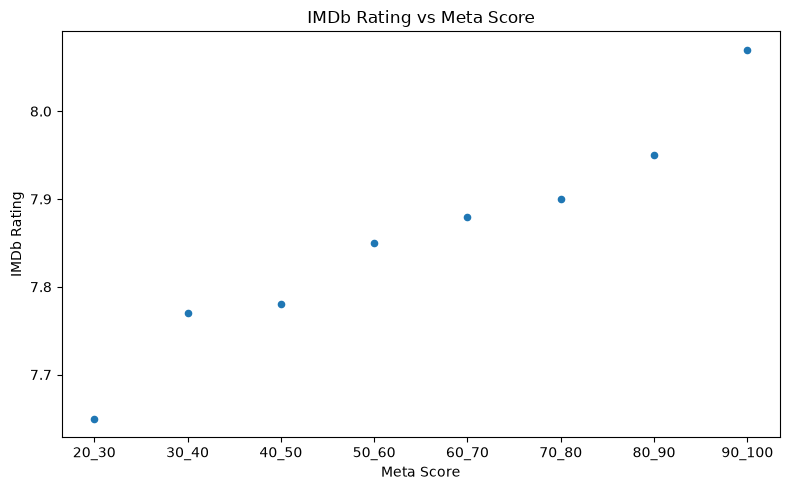

In [84]:
fig, ax = plt.subplots(figsize=(8, 5))

mean_rating.plot(
    x="Meta Score Binning",
    y="Mean IMDB Rating",
    kind="scatter",
    ax=ax
)

ax.set_title("IMDb Rating vs Meta Score")
ax.set_xlabel("Meta Score")
ax.set_ylabel("IMDb Rating")

plt.tight_layout()
plt.show()